# Wage Patterns in the Ukrainian IT Labor Market
## A Descriptive Econometric Analysis

**Lukashenko Polina, Mandryk Sophia, Onopriienko Daryna**  
Econometrics 2026 — UCU, Lviv

---


## 0. Configuration & Imports

In [31]:

RAW_DATA_PATH = 'salaries_2018_2025.csv'
OUTPUT_DIR    = './figures'
SEED          = 42

import os, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from scipy.stats import f as f_dist, pearsonr
import statsmodels.api as sm
from statsmodels.regression.linear_model   import OLS
from statsmodels.tools.tools               import add_constant
from statsmodels.stats.diagnostic          import het_breuschpagan, linear_reset
from statsmodels.stats.outliers_influence  import variance_inflation_factor

warnings.filterwarnings('ignore')
os.makedirs(OUTPUT_DIR, exist_ok=True)

BLUE = '#2B4C7E'; RED = '#C0392B'; GRAY = '#566573'; ORG = '#E67E22'
plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.family'      : 'serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
print('Imports OK')

Imports OK


## 1. Data Cleaning

The raw DOU survey file contains **208,081** observations from 16 survey waves (2018–2025).  
We apply the following cleaning steps, documenting every removal decision.

### 1.1 Load raw data

In [2]:
raw = pd.read_csv(RAW_DATA_PATH, low_memory=False)
print(f'Raw dataset: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
print(f'Columns: {list(raw.columns)}')
display(raw.head(3))

Raw dataset: 208,081 rows x 18 columns
Columns: ['survey_date', 'salary', 'title', 'position', 'specialization', 'experience_total', 'experience_current', 'city', 'company_size', 'company_type', 'gender', 'age', 'education', 'english_level', 'primary_language', 'salary_change', 'domain', 'source_file']


,survey_date,salary,title,position,specialization,experience_total,experience_current,city,company_size,company_type,gender,age,education,english_level,primary_language,salary_change,domain,source_file
0,2018-06,500.0,NaN,Software Engineer,NaN,10.0,10.0,Суми,до 50,Інша,Male,37.0,Вища,Pre-Intermediate,C++,100.0,"Desktop Applications,Корпоративные системы",2018_june_final.csv
1,2018-06,1500.0,NaN,Senior QA engineer,Manual QA,4.0,3.0,Дніпро,до 50,Продуктова,Female,25.0,Вища,Intermediate,NaN,500.0,"iOS,Desktop Applications",2018_june_final.csv
2,2018-06,2720.0,NaN,Software Engineer,NaN,10.0,4.0,Харків,до 200,Продуктова,Male,40.0,Вища,Intermediate,JavaScript,120.0,"Веб-разработка,Корпоративные системы",2018_june_final.csv


### 1.2 Rename columns and create derived variables

In [ ]:
df = raw.copy()

df = df.rename(columns={'salary': 'salary_usd', 'position': 'job_title'})

df['experience'] = df['experience_total']

removal_log = {}
print('Renamed: salary -> salary_usd,  position -> job_title')
print('Created: experience = experience_total')

Renamed: salary -> salary_usd,  position -> job_title
Created: experience = experience_total


### 1.3 Salary: remove missing and implausible values

- Lower bound **$300/month**: values below this likely represent trainee salaries 
entered without USD conversion.
- Upper bound **$9,000/month**: one extreme outlier ($77,251, a likely data-entry error) 
is removed; the next highest value is $9,000.

In [ ]:
before = len(df)
df = df[df['salary_usd'].notna()].copy()
removal_log['Missing salary'] = before - len(df)
print(f'Removed missing salary: -{before - len(df):,} rows')

SALARY_MIN, SALARY_MAX = 300, 9_000
before = len(df)
df = df[(df['salary_usd'] >= SALARY_MIN) & (df['salary_usd'] <= SALARY_MAX)].copy()
removal_log[f'Salary outside [{SALARY_MIN}, {SALARY_MAX}]'] = before - len(df)
print(f'Removed salary outliers: -{before - len(df):,} rows  ->  N = {len(df):,}')
print(f'  (includes values below $300 and the $77,251 data-entry error)')

Removed missing salary: -767 rows
Removed salary outliers: -3,233 rows  ->  N = 204,081
  (includes values below $300 and the $77,251 data-entry error)


### 1.4 English level: remove missing and uninterpretable values

In [ ]:
before = len(df)
df = df[df['english_level'].notna()].copy()
df = df[df['english_level'] != 'Not знаю взагалi'].copy()
df = df[df['english_level'] != '\u041d\u0435 \u0437\u043d\u0430\u044e \u0432\u0437\u0430\u0433\u0430\u043b\u0456'].copy()
removal_log['Missing / unusable English level'] = before - len(df)
print(f'Removed bad English level: -{before - len(df):,} rows  ->  N = {len(df):,}')

ENGLISH_MAP = {
    'Elementary'        : 1,
    'Pre-Intermediate'  : 2,
    'Intermediate'      : 3,
    'Upper-Intermediate': 4,
    'Advanced'          : 5,
}
df['english'] = df['english_level'].map(ENGLISH_MAP)
print('English distribution:', df['english_level'].value_counts().to_dict())

Removed bad English level: -26,828 rows  ->  N = 177,253
English distribution: {'Upper-Intermediate': 71921, 'Intermediate': 58097, 'Advanced': 22979, 'Pre-Intermediate': 20060, 'Elementary': 4196}


### 1.5 Experience: remove missing and out-of-range values

In [6]:
EXP_MIN, EXP_MAX = 0.1, 25.0
before = len(df)
df = df[df['experience_total'].notna()].copy()
df = df[(df['experience_total'] >= EXP_MIN) & (df['experience_total'] <= EXP_MAX)].copy()
df['experience'] = df['experience_total']  # re-assign after filter
removal_log['Missing / out-of-range experience'] = before - len(df)
print(f'Removed bad experience: -{before - len(df):,} rows  ->  N = {len(df):,}')

Removed bad experience: -3,520 rows  ->  N = 173,733


### 1.6 Derive analysis columns

In [ ]:
df['year']       = df['survey_date'].str[:4].astype(int)
df['log_salary'] = np.log(df['salary_usd'])
df['exp2']       = df['experience'] ** 2

# Gender: Female=1, Male=0, missing=NaN
# NaN rows kept; excluded only in gender models
df['female'] = np.where(df['gender'] == 'Female', 1.0,
               np.where(df['gender'] == 'Male',   0.0, np.nan))

df['eng_label'] = df['english'].map({
    1:'Elementary', 2:'Pre-Intermediate', 3:'Intermediate',
    4:'Upper-Intermediate', 5:'Advanced'
})

df['title_clean'] = df['title'].fillna('No Title').astype(str).str.strip()
df.loc[df['title_clean'] == 'nan', 'title_clean'] = 'No Title'

def assign_era(y):
    if y <= 2019: return 'Pre-boom (2018-19)'
    if y <= 2021: return 'Tech boom (2020-21)'
    if y == 2022: return 'War onset (2022)'
    return 'In-war (2023-25)'

df['era'] = df['year'].apply(assign_era)
ERA_ORDER = ['Pre-boom (2018-19)','Tech boom (2020-21)',
             'War onset (2022)','In-war (2023-25)']

print('===================================================')
print(f'  FINAL CLEANED DATASET: N = {len(df):,}')
print('===================================================')

  FINAL CLEANED DATASET: N = 173,733


### 1.7 Removal summary

In [8]:
removal_df = pd.DataFrame({
    'Reason'      : list(removal_log.keys()),
    'Rows removed': list(removal_log.values()),
})
removal_df['% of raw'] = (removal_df['Rows removed'] / len(raw) * 100).round(2)
removal_df.loc[len(removal_df)] = [
    'TOTAL REMOVED',
    sum(removal_log.values()),
    round(sum(removal_log.values()) / len(raw) * 100, 2)
]
display(removal_df)
print(f'\nRaw: {len(raw):,}  ->  Final: {len(df):,}  '
      f'({(len(raw)-len(df))/len(raw)*100:.1f}% removed)')

,Reason,Rows removed,% of raw
0,Missing salary,767,0.37
1,"Salary outside [300, 9000]",3233,1.55
2,Missing / unusable English level,26828,12.89
3,Missing / out-of-range experience,3520,1.69
4,TOTAL REMOVED,34348,16.51



Raw: 208,081  ->  Final: 173,733  (16.5% removed)


### 1.8 Save cleaned dataset to disk

In [9]:
# ===================================================
# Save cleaned dataset to disk
# ===================================================
CLEAN_PATH = './salaries_2018_2025_clean.csv'

df.to_csv(CLEAN_PATH, index=False)
print(f'Cleaned dataset saved to: {CLEAN_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Cleaned dataset saved to: ./salaries_2018_2025_clean.csv
Shape: 173,733 rows x 27 columns
Columns: ['survey_date', 'salary_usd', 'title', 'job_title', 'specialization', 'experience_total', 'experience_current', 'city', 'company_size', 'company_type', 'gender', 'age', 'education', 'english_level', 'primary_language', 'salary_change', 'domain', 'source_file', 'experience', 'english', 'year', 'log_salary', 'exp2', 'female', 'eng_label', 'title_clean', 'era']


## 2. Exploratory Data Analysis

### 2.1 Summary statistics by market era

In [10]:
def p9010(x): return np.percentile(x, 90) / np.percentile(x, 10)

t1 = df.groupby('era').agg(
    N          = ('salary_usd', 'count'),
    Median_USD = ('salary_usd', 'median'),
    SD_log     = ('log_salary', 'std'),
    P90_P10    = ('salary_usd', p9010),
    Pct_Female = ('female',     'mean'),
).reindex(ERA_ORDER)
t1['Pct_Female'] = (t1['Pct_Female'] * 100).round(1)
print('Table 1: Summary Statistics by Market Era')
display(t1.round(3))

Table 1: Summary Statistics by Market Era


,N,Median_USD,SD_log,P90_P10,Pct_Female
era,,,,,
Pre-boom (2018-19),39992,1700.0,0.744,7.547,20.3
Tech boom (2020-21),47884,2300.0,0.734,7.143,22.2
War onset (2022),12643,2700.0,0.738,7.250,23.2
In-war (2023-25),73214,2700.0,0.722,6.824,26.7


### 2.2 Descriptive statistics

In [11]:
t2 = (df[['salary_usd','log_salary','experience','english']]
        .describe().T[['mean','50%','std','min','max']].round(2))
t2.index  = ['Salary (USD)','log(Salary)','Experience (yrs)','English (1-5)']
t2.columns = ['Mean','Median','SD','Min','Max']
print('Table 2: Descriptive Statistics')
display(t2)

Table 2: Descriptive Statistics


,Mean,Median,SD,Min,Max
Salary (USD),2683.76,2300.00,1775.11,300.0,9000.0
log(Salary),7.65,7.74,0.75,5.7,9.1
Experience (yrs),4.77,4.00,3.37,0.1,25.0
English (1-5),3.51,4.00,0.94,1.0,5.0


### 2.3 Pearson correlations

In [12]:
corr_df = df[['log_salary','experience','english','female']].dropna()
print('Table 3: Pearson Correlation Matrix')
display(corr_df.corr().round(3))
for a, b in [('log_salary','experience'),('log_salary','english'),
             ('log_salary','female'),('experience','english')]:
    r, p = pearsonr(corr_df[a], corr_df[b])
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
    print(f'  r({a:>12}, {b:>10}) = {r:+.3f}  {sig}')

Table 3: Pearson Correlation Matrix


,log_salary,experience,english,female
log_salary,1.000,0.567,0.310,-0.250
experience,0.567,1.000,0.140,-0.137
english,0.310,0.140,1.000,0.108
female,-0.250,-0.137,0.108,1.000


  r(  log_salary, experience) = +0.567  ***
  r(  log_salary,    english) = +0.310  ***
  r(  log_salary,     female) = -0.250  ***
  r(  experience,    english) = +0.140  ***


### 2.4 Figure 1 — Salary distribution before and after log transformation

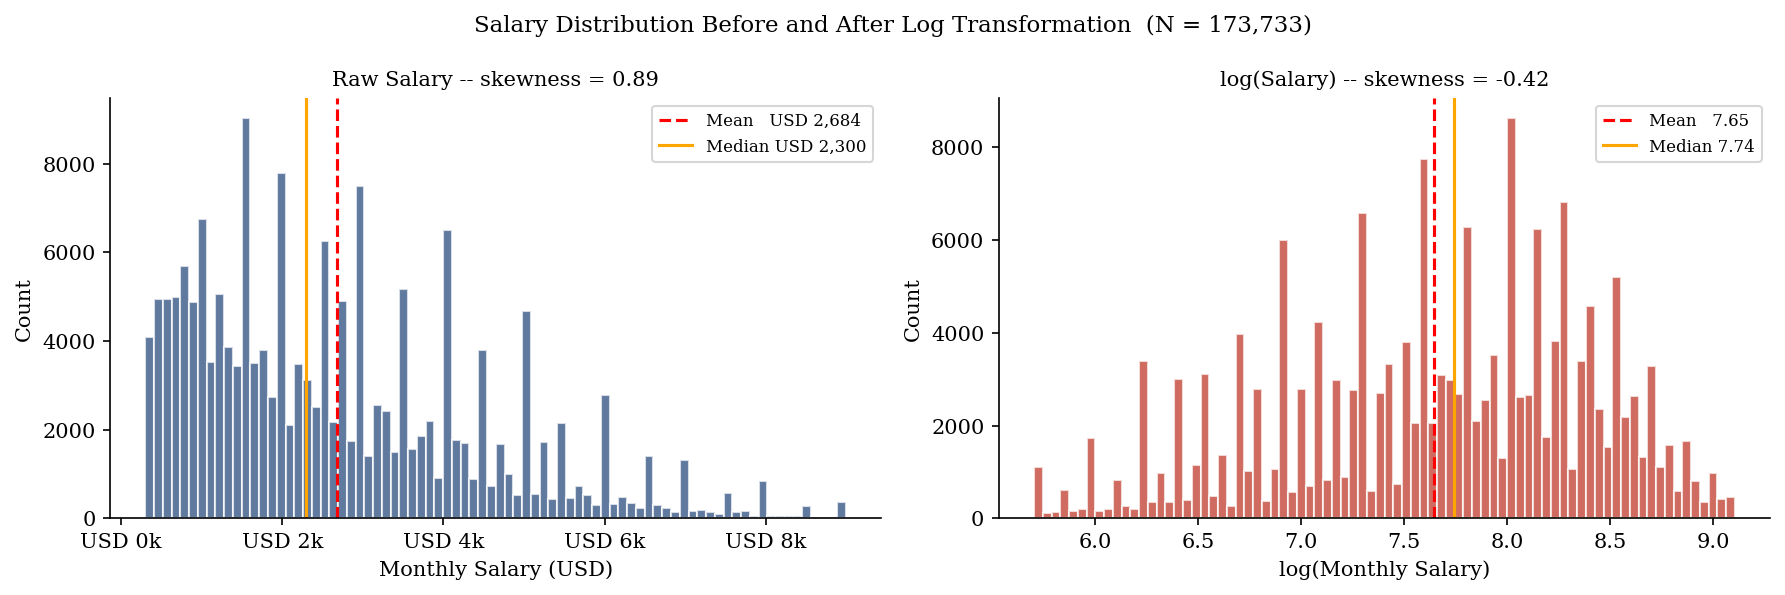

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color, xlabel in [
    (axes[0], 'salary_usd', BLUE, 'Monthly Salary (USD)'),
    (axes[1], 'log_salary', RED,  'log(Monthly Salary)'),
]:
    ax.hist(df[col], bins=80, color=color, alpha=0.75, edgecolor='white')
    if col == 'salary_usd':
        mean_lbl   = f'Mean   USD {df[col].mean():,.0f}'
        median_lbl = f'Median USD {df[col].median():,.0f}'
    else:
        mean_lbl   = f'Mean   {df[col].mean():.2f}'
        median_lbl = f'Median {df[col].median():.2f}'
    ax.axvline(df[col].mean(),   color='red',    ls='--', lw=1.5, label=mean_lbl)
    ax.axvline(df[col].median(), color='orange', ls='-',  lw=1.5, label=median_lbl)
    ax.set_title(
        f'{"Raw Salary" if col=="salary_usd" else "log(Salary)"}'
        f' -- skewness = {df[col].skew():.2f}', fontsize=10)
    ax.set_xlabel(xlabel); ax.set_ylabel('Count'); ax.legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'USD {x/1000:.0f}k'))
fig.suptitle(
    f'Salary Distribution Before and After Log Transformation  (N = {len(df):,})',
    fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_distribution.png', bbox_inches='tight')
plt.show()

### 2.5 Figure 2 — Share of women by job title

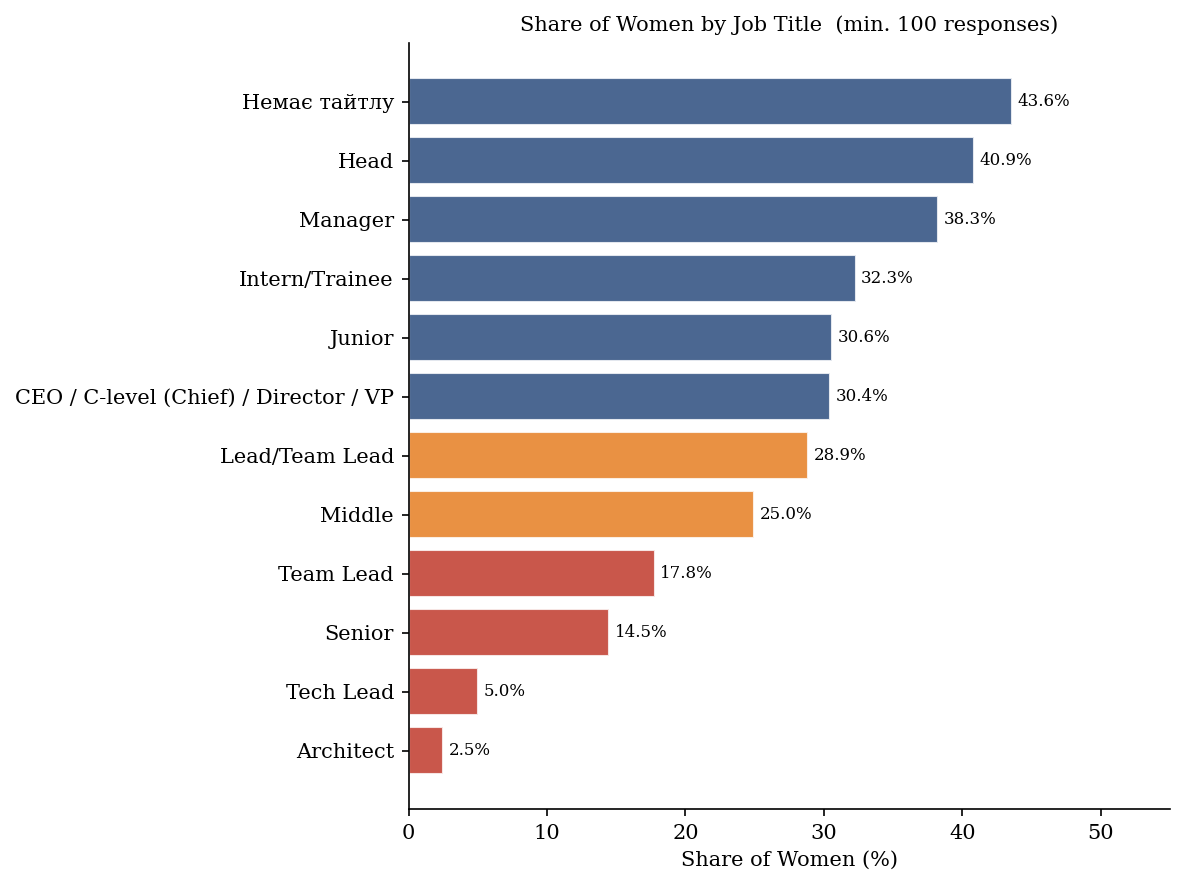

Key numbers for leaky-pipeline argument:
  Architect                               : 2.5%  (n=1,008)
  Tech Lead                               : 5.0%  (n=3,156)
  Senior                                  : 14.5%  (n=24,568)
  Team Lead                               : 17.8%  (n=5,240)
  Middle                                  : 25.0%  (n=30,973)
  Lead/Team Lead                          : 28.9%  (n=1,275)
  CEO / C-level (Chief) / Director / VP   : 30.4%  (n=207)
  Junior                                  : 30.6%  (n=13,031)
  Intern/Trainee                          : 32.3%  (n=796)
  Manager                                 : 38.3%  (n=1,464)
  Head                                    : 40.9%  (n=1,368)
  Немає тайтлу                            : 43.6%  (n=2,818)


In [29]:
df_g  = df[df['gender'].notna() & (df['title_clean'] != 'No Title')].copy()
share = (df_g.groupby('title_clean')
             .agg(n=('gender','count'), f=('female','mean'))
             .query('n >= 100')
             .assign(pct=lambda x: x['f'] * 100)
             .sort_values('pct'))

fig, ax = plt.subplots(figsize=(8, 6))
colors = [RED if p < 20 else ORG if p < 30 else BLUE for p in share['pct']]
bars   = ax.barh(share.index, share['pct'], color=colors, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, share['pct']):
    ax.text(v + 0.4, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlabel('Share of Women (%)')
ax.set_xlim(0, 55)
ax.set_title('Share of Women by Job Title  (min. 100 responses)', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_women_share.png', bbox_inches='tight')
plt.show()
print('Key numbers for leaky-pipeline argument:')
for idx, row in share.iterrows():
    print(f'  {idx:40s}: {row["pct"]:.1f}%  (n={int(row["n"]):,})')

## 3. Regression Models

**Dependent variable:** `log(salary_usd)` — log of monthly salary in USD  
**Key independent variables:** experience, exp^2, title dummies, English dummies, female, year FE  
All models use **HC1 heteroskedasticity-robust standard errors** (justified in Section 4).

### 3.1 Model 1 (H1) — Mincerian Baseline

$log(salary_i) = b0 + b1 * \exp_i + b2 * \exp_i^2 + u_i$

In [15]:
X1     = add_constant(df[['experience','exp2']].astype(float))
m1     = OLS(df['log_salary'].values, X1.values).fit(cov_type='HC1')
m1_names = list(X1.columns)

b0, b1, b2 = m1.params
xstar = -b1 / (2 * b2)

print('=' * 60)
print('MODEL 1: Mincerian Baseline')
print('=' * 60)
print(f'  const      : {b0:.4f}  SE={m1.bse[0]:.4f}  t={m1.tvalues[0]:,.1f}***')
print(f'  experience : {b1:.4f}  SE={m1.bse[1]:.4f}  t={m1.tvalues[1]:,.1f}***')
print(f'  exp2       : {b2:.4f}  SE={m1.bse[2]:.4f}  t={m1.tvalues[2]:,.1f}***')
print(f'  R-squared  : {m1.rsquared:.4f}')
print(f'  F-stat     : {m1.fvalue:.1f}  (p < 0.001)')
print(f'  N          : {int(m1.nobs):,}')
print(f'\n  Wage-experience peak:')
print(f'  x* = {b1:.4f} / (2 x {abs(b2):.4f}) = {xstar:.2f} years')

MODEL 1: Mincerian Baseline
  const      : 6.6397  SE=0.0039  t=1,696.0***
  experience : 0.3066  SE=0.0014  t=211.7***
  exp2       : -0.0134  SE=0.0001  t=-122.5***
  R-squared  : 0.4076
  F-stat     : 58533.7  (p < 0.001)
  N          : 173,733

  Wage-experience peak:
  x* = 0.3066 / (2 x 0.0134) = 11.44 years


### 3.2 Figure 3 — Mincerian curve and marginal returns

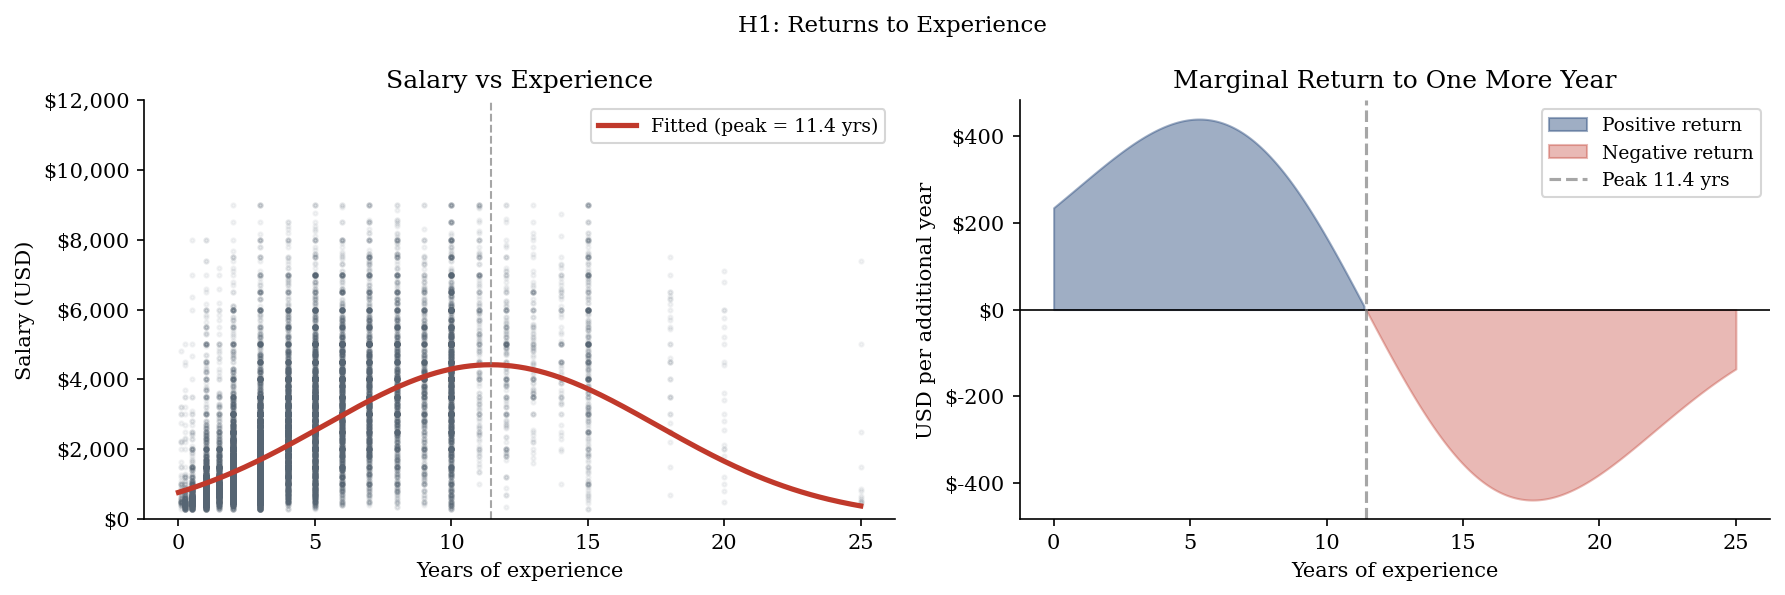

H1: b1=0.3066***, b2=-0.0134***, peak=11.4 yrs  -> SUPPORTED


In [16]:
exp_grid   = np.linspace(0, 25, 300)
fitted_log = b0 + b1*exp_grid + b2*exp_grid**2
fitted_usd = np.exp(fitted_log)
marg_usd   = (b1 + 2*b2*exp_grid) * np.exp(fitted_log)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
samp = df.sample(min(20_000, len(df)), random_state=SEED)
axes[0].scatter(samp['experience'], samp['salary_usd'],
                alpha=0.07, s=4, color=GRAY)
axes[0].plot(exp_grid, fitted_usd, color=RED, lw=2.5,
             label=f'Fitted (peak = {xstar:.1f} yrs)')
axes[0].axvline(xstar, ls='--', color='grey', alpha=0.7, lw=1)
axes[0].set_ylim(0, 12_000)
axes[0].set_xlabel('Years of experience'); axes[0].set_ylabel('Salary (USD)')
axes[0].set_title('Salary vs Experience'); axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:,.0f}'))

axes[1].fill_between(exp_grid, marg_usd, where=(marg_usd >= 0),
                     color=BLUE, alpha=0.45, label='Positive return')
axes[1].fill_between(exp_grid, marg_usd, where=(marg_usd  < 0),
                     color=RED,  alpha=0.35, label='Negative return')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(xstar, ls='--', color='grey', alpha=0.7,
                label=f'Peak {xstar:.1f} yrs')
axes[1].set_xlabel('Years of experience')
axes[1].set_ylabel('USD per additional year')
axes[1].set_title('Marginal Return to One More Year'); axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:,.0f}'))

fig.suptitle('H1: Returns to Experience', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_h1_mincerian.png', bbox_inches='tight')
plt.show()
print(f'H1: b1={b1:.4f}***, b2={b2:.4f}***, peak={xstar:.1f} yrs  -> SUPPORTED')

### 3.3 Model 2 (H2) — Adding Job Title Dummies and English Level

$log(salary_i) = b0 + b1*\exp + b2*\exp^2 + sum(\gamma_j * Title_j) + sum(\delta_k * English_k) + u$

In [17]:
# Build dummy variables
t_dummies = pd.get_dummies(df['title_clean'], prefix='T', dtype=float)
if 'T_Architect' in t_dummies.columns:
    t_dummies = t_dummies.drop(columns=['T_Architect'])  # baseline

e_dummies = pd.get_dummies(df['eng_label'], prefix='E', dtype=float)
if 'E_Pre-Intermediate' in e_dummies.columns:
    e_dummies = e_dummies.drop(columns=['E_Pre-Intermediate'])  # baseline

print(f'Title dummies  : {t_dummies.shape[1]} categories (baseline: Architect)')
print(f'English dummies: {e_dummies.shape[1]} categories (baseline: Pre-Intermediate)')

Title dummies  : 20 categories (baseline: Architect)
English dummies: 4 categories (baseline: Pre-Intermediate)


In [18]:
# Model 2a: + title dummies
X2a_df   = pd.concat([df[['experience','exp2']].astype(float), t_dummies], axis=1).astype(float)
m2a      = OLS(df['log_salary'].values, add_constant(X2a_df).values).fit(cov_type='HC1')
m2a_names = ['const'] + list(X2a_df.columns)

# Model 2b: + title dummies + English
X2b_df   = pd.concat([df[['experience','exp2']].astype(float), t_dummies, e_dummies], axis=1).astype(float)
m2b      = OLS(df['log_salary'].values, add_constant(X2b_df).values).fit(cov_type='HC1')
m2b_names = ['const'] + list(X2b_df.columns)

exp_m2a  = m2a.params[m2a_names.index('experience')]
exp_drop = (1 - exp_m2a / b1) * 100

# F-test: all title dummies jointly = 0
title_idx = [m2a_names.index(c) for c in m2a_names if c.startswith('T_')]
R_mat = np.zeros((len(title_idx), len(m2a.params)))
for i, j in enumerate(title_idx): R_mat[i, j] = 1
f_joint   = m2a.f_test(R_mat)

print('=' * 60)
print('MODEL 2: +Title Dummies and English Level')
print('=' * 60)
print(f'  R-sq: M1={m1.rsquared:.4f}  M2a={m2a.rsquared:.4f}  M2b={m2b.rsquared:.4f}')
print(f'  Experience coeff: {b1:.4f} -> {exp_m2a:.4f}  ({exp_drop:.1f}% reduction)')
print(f'  F-test titles jointly zero: F={float(f_joint.fvalue):.1f}, p < 0.001')
print()
print('  English coefficients vs Pre-Intermediate baseline:')
for k in ['E_Advanced','E_Upper-Intermediate','E_Intermediate','E_Elementary']:
    if k in m2b_names:
        i = m2b_names.index(k)
        c = m2b.params[i]; t_v = m2b.tvalues[i]
        print(f'    {k:28s}: b={c:+.4f}  ({(np.exp(c)-1)*100:+.1f}%)  t={t_v:.1f}***')

MODEL 2: +Title Dummies and English Level
  R-sq: M1=0.4076  M2a=0.5289  M2b=0.5625
  Experience coeff: 0.3066 -> 0.2224  (27.5% reduction)
  F-test titles jointly zero: F=2140.6, p < 0.001

  English coefficients vs Pre-Intermediate baseline:
    E_Advanced                  : b=+0.4117  (+50.9%)  t=78.4***
    E_Upper-Intermediate        : b=+0.3600  (+43.3%)  t=82.3***
    E_Intermediate              : b=+0.2139  (+23.8%)  t=48.2***
    E_Elementary                : b=-0.1768  (-16.2%)  t=-17.0***


### 3.4 Figure 4 — Title wage premiums

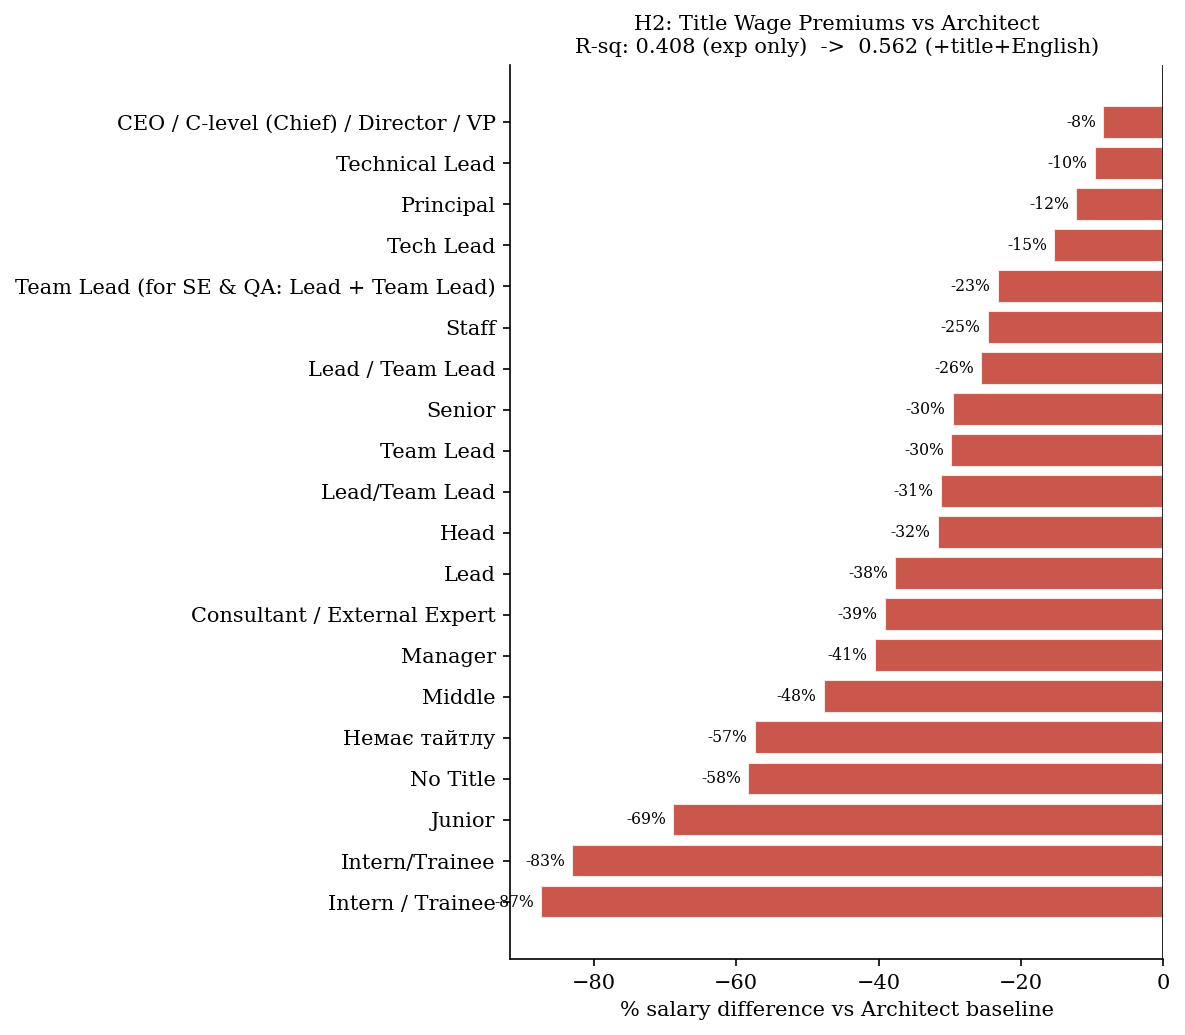

In [19]:
tc = {
    c.replace('T_', ''): (np.exp(m2b.params[m2b_names.index(c)]) - 1) * 100
    for c in m2b_names if c.startswith('T_')
}
tc_sorted = sorted(tc.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(8, 7))
names = [x[0] for x in tc_sorted]
vals  = [x[1] for x in tc_sorted]
bars  = ax.barh(names, vals,
                color=[RED if v < 0 else BLUE for v in vals],
                alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
for bar, v in zip(bars, vals):
    ax.text(v - 1 if v < 0 else v + 1,
            bar.get_y() + bar.get_height()/2,
            f'{v:.0f}%', va='center',
            ha='right' if v < 0 else 'left', fontsize=7.5)
ax.set_xlabel('% salary difference vs Architect baseline')
ax.set_title(
    f'H2: Title Wage Premiums vs Architect\n'
    f'R-sq: {m1.rsquared:.3f} (exp only)  ->  {m2b.rsquared:.3f} (+title+English)',
    fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_h2_title_premiums.png', bbox_inches='tight')
plt.show()

### 3.5 Model 3 (H3) — Full Specification: Gender Interaction + Year Fixed Effects

Sample restricted to rows with non-missing gender (N ~ 151,000).

In [20]:
df3 = df.dropna(subset=['female']).copy()
df3['fem_x_exp'] = df3['female'] * df3['experience']

t3 = pd.get_dummies(df3['title_clean'], prefix='T', dtype=float)
if 'T_Architect' in t3.columns: t3 = t3.drop(columns=['T_Architect'])
e3 = pd.get_dummies(df3['eng_label'], prefix='E', dtype=float)
if 'E_Pre-Intermediate' in e3.columns: e3 = e3.drop(columns=['E_Pre-Intermediate'])
y3 = pd.get_dummies(df3['year'], prefix='yr', dtype=float, drop_first=True)  # baseline: 2018

X3_df    = pd.concat([
    df3[['experience','exp2','female','fem_x_exp']].astype(float),
    t3, e3, y3
], axis=1).astype(float)
m3_names = ['const'] + list(X3_df.columns)
m3       = OLS(df3['log_salary'].values, add_constant(X3_df).values).fit(cov_type='HC1')

theta  = m3.params[m3_names.index('female')]
lam    = m3.params[m3_names.index('fem_x_exp')]
se_th  = m3.bse  [m3_names.index('female')]
se_lm  = m3.bse  [m3_names.index('fem_x_exp')]
t_th   = m3.tvalues[m3_names.index('female')]
t_lm   = m3.tvalues[m3_names.index('fem_x_exp')]

print('=' * 60)
print('MODEL 3: Full Specification')
print('=' * 60)
print(f'  R-squared  : {m3.rsquared:.4f}   N = {int(m3.nobs):,}')
print(f'  Female (theta)   : {theta:.4f}  SE={se_th:.4f}  t={t_th:.1f}***')
print(f'  Female x exp (lambda): {lam:.4f}  SE={se_lm:.4f}  t={t_lm:.1f}***')
print()
print('  Gender wage gap at selected experience levels:')
for v in [0, 3, 5, 10, 15]:
    gap = theta + lam * v
    print(f'    {v:2d} yrs: {(np.exp(gap)-1)*100:.1f}%')

MODEL 3: Full Specification
  R-squared  : 0.6014   N = 151,104
  Female (theta)   : -0.3019  SE=0.0061  t=-49.2***
  Female x exp (lambda): -0.0070  SE=0.0014  t=-5.1***

  Gender wage gap at selected experience levels:
     0 yrs: -26.1%
     3 yrs: -27.6%
     5 yrs: -28.6%
    10 yrs: -31.1%
    15 yrs: -33.5%


### 3.6 Figure 5 — Gender wage gap over career

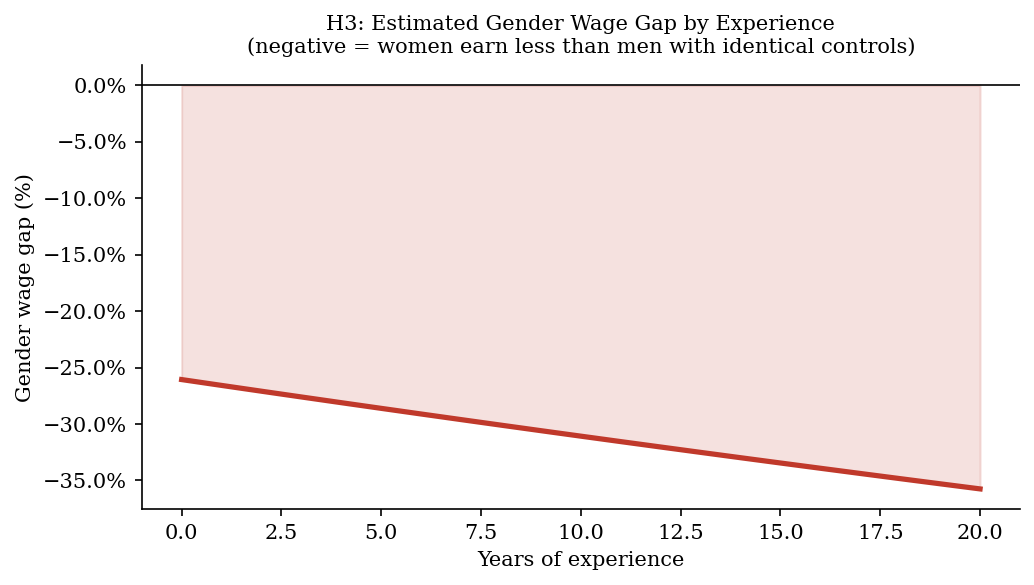

In [21]:
ev      = np.arange(0, 21)
gap_pct = (np.exp(theta + lam * ev) - 1) * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ev, gap_pct, color=RED, lw=2.5)
ax.fill_between(ev, gap_pct, alpha=0.15, color=RED)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Years of experience')
ax.set_ylabel('Gender wage gap (%)')
ax.set_title(
    'H3: Estimated Gender Wage Gap by Experience\n'
    '(negative = women earn less than men with identical controls)',
    fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_h3_gender_gap.png', bbox_inches='tight')
plt.show()

## 5. OLS Assumption Tests

OLS valid under: (1) linearity, (2) random sample, (3) no perfect multicollinearity, 
(4) zero conditional mean, (5) homoskedasticity, (6) normality.  
We test (3), (5), (6) formally.

In [30]:
# A1: Heteroskedasticity -- Breusch-Pagan
bp1_lm, bp1_p, _, _ = het_breuschpagan(m1.resid, m1.model.exog)
bp3_lm, bp3_p, _, _ = het_breuschpagan(m3.resid, m3.model.exog)
print('Breusch-Pagan Test (H0: homoskedastic errors)')
print(f'  Model 1: LM={bp1_lm:.2f}, p={bp1_p:.2e}  -> REJECT H0')
print(f'  Model 3: LM={bp3_lm:.2f}, p={bp3_p:.2e}  -> REJECT H0')
print('  Conclusion: HC1 robust SEs are justified throughout.')

print()
# A2: Multicollinearity -- VIF
vif_X = add_constant(df[['experience','exp2']].astype(float))
vifs  = [variance_inflation_factor(vif_X.values, i) for i in range(vif_X.shape[1])]
print('VIF (Model 1):')
for name, v in zip(list(vif_X.columns), vifs):
    print(f'  {name:15s}: VIF = {v:.2f}')
print('  High VIF for exp/exp^2 is expected (same base variable). Not a concern.')

print()
# A3: Normality 
print('  With N=173,000+, CLT ensures asymptotic normality of OLS estimator.')
print('  Non-normality of residuals does not invalidate inference.')

print()
# A4: Functional form -- RESET
reset_m1 = linear_reset(m1, power=2, use_f=True)
print(f'RESET Test (Model 1): F={reset_m1.fvalue:.2f}, p={reset_m1.pvalue:.4f} -> REJECT H0')
print('  Expected in M1 (omits title/English/year). Models 2-3 address this.')

Breusch-Pagan Test (H0: homoskedastic errors)
  Model 1: LM=860.21, p=1.61e-187  -> REJECT H0
  Model 3: LM=6249.76, p=0.00e+00  -> REJECT H0
  Conclusion: HC1 robust SEs are justified throughout.

VIF (Model 1):
  const          : VIF = 6.14
  experience     : VIF = 7.96
  exp2           : VIF = 7.96
  High VIF for exp/exp^2 is expected (same base variable). Not a concern.

  With N=173,000+, CLT ensures asymptotic normality of OLS estimator.
  Non-normality of residuals does not invalidate inference.

RESET Test (Model 1): F=5564.68, p=0.0000 -> REJECT H0
  Expected in M1 (omits title/English/year). Models 2-3 address this.


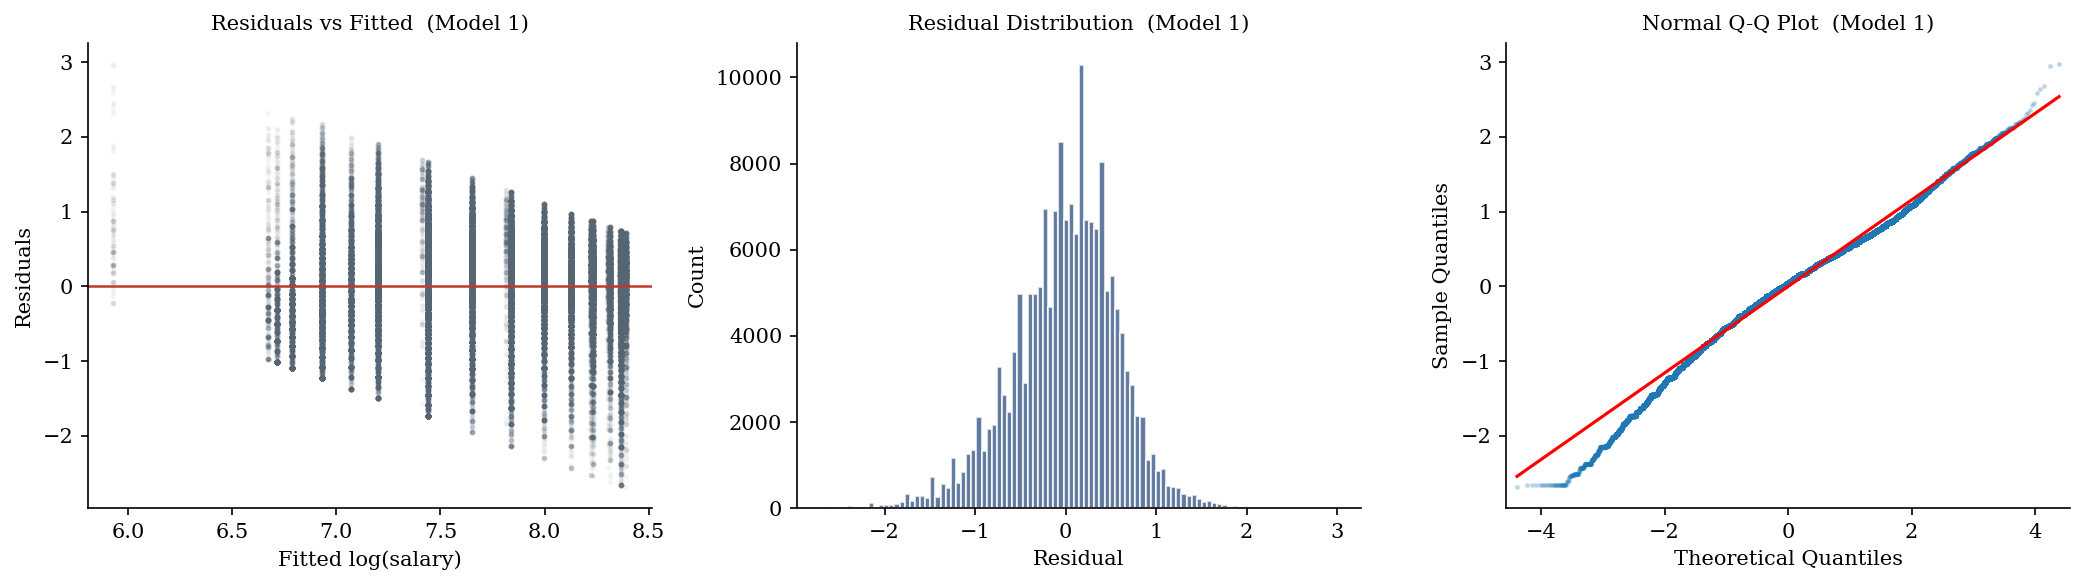

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(m1.fittedvalues, m1.resid, alpha=0.04, s=3, color=GRAY)
axes[0].axhline(0, color=RED, lw=1.2)
axes[0].set_xlabel('Fitted log(salary)'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted  (Model 1)', fontsize=10)

axes[1].hist(m1.resid, bins=100, color=BLUE, alpha=0.75, edgecolor='white')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution  (Model 1)', fontsize=10)

sm.qqplot(m1.resid, line='s', ax=axes[2], alpha=0.2, markersize=1.5, color=BLUE)
axes[2].set_title('Normal Q-Q Plot  (Model 1)', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6_assumptions.png', bbox_inches='tight')
plt.show()

## 6. Structural Break: Chow Test (H4)

In [24]:
def chow_test(data, break_year):
    """Compute Chow F-statistic for a break at break_year."""
    pre  = data[data['year'] <  break_year]
    post = data[data['year'] >= break_year]

    def fit_rss(d):
        X = add_constant(d[['experience','exp2']].astype(float))
        return OLS(d['log_salary'].values, X.values).fit().ssr, len(d)

    X_full = add_constant(data[['experience','exp2']].astype(float))
    rss_F  = OLS(data['log_salary'].values, X_full.values).fit().ssr
    rss1, n1 = fit_rss(pre)
    rss2, n2 = fit_rss(post)
    k = 3
    F_stat = ((rss_F - rss1 - rss2) / k) / ((rss1 + rss2) / (n1 + n2 - 2*k))
    p_val  = 1 - f_dist.cdf(F_stat, dfn=k, dfd=n1+n2-2*k)
    return F_stat, p_val, n1, n2

chow_data = df.dropna(subset=['log_salary','experience','exp2'])
print(f'{"Break year":>12} {"F-stat":>10} {"p-value":>10} {"n_pre":>9} {"n_post":>9}')
print('-' * 55)
chow_results = {}
for yr in [2020, 2022]:
    F, p, n1, n2 = chow_test(chow_data, yr)
    chow_results[yr] = (F, p, n1, n2)
    print(f'{yr:>12} {F:>10.1f} {"<0.001":>10} {n1:>9,} {n2:>9,}')

  Break year     F-stat    p-value     n_pre    n_post
-------------------------------------------------------
        2020     2425.8     <0.001    39,992   133,741
        2022     2739.3     <0.001    87,876    85,857


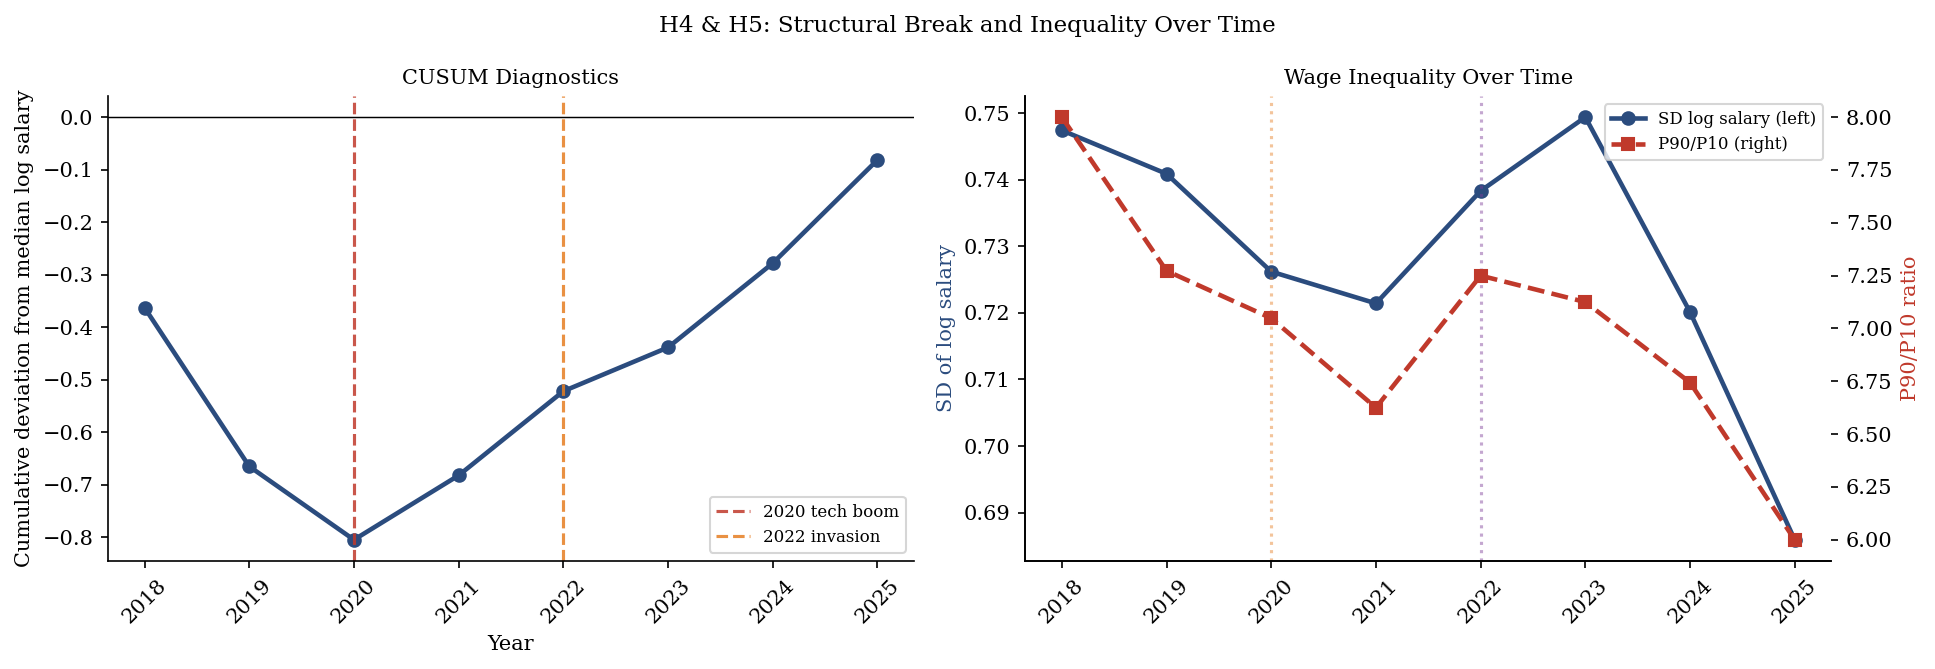

Inequality Table:


,year,SD_log,P9010,Median,N
0,2018,0.747,8.000,1600.0,19154
1,2019,0.741,7.273,1700.0,20838
2,2020,0.726,7.048,2000.0,21709
3,2021,0.721,6.625,2600.0,26175
4,2022,0.738,7.250,2700.0,12643
5,2023,0.749,7.125,2500.0,25560
6,2024,0.720,6.744,2700.0,25025
7,2025,0.686,6.000,2800.0,22629


In [ ]:
annual = df.groupby('year').agg(
    med_log = ('log_salary', 'median'),
    SD_log  = ('log_salary', 'std'),
    P9010   = ('salary_usd', p9010),
    Median  = ('salary_usd', 'median'),
    N       = ('salary_usd', 'count'),
).reset_index()

cusum = (annual['med_log'] - df['log_salary'].median()).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(annual['year'], cusum.values, 'o-', color=BLUE, lw=2.2, ms=6)
axes[0].axhline(0, color='black', lw=0.7)
axes[0].axvline(2020, ls='--', color=RED, lw=1.5, alpha=0.85, label='2020 tech boom')
axes[0].axvline(2022, ls='--', color=ORG, lw=1.5, alpha=0.85, label='2022 invasion')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Cumulative deviation from median log salary')
axes[0].set_title('CUSUM Diagnostics', fontsize=10); axes[0].legend(fontsize=8)
axes[0].set_xticks(annual['year']); axes[0].tick_params(axis='x', rotation=45)

ax2  = axes[1]; ax2b = ax2.twinx()
ax2.plot(annual['year'],  annual['SD_log'], 'o-',  color=BLUE, lw=2.2, ms=6, label='SD log salary (left)')
ax2b.plot(annual['year'], annual['P9010'],  's--', color=RED,  lw=2.2, ms=6, label='P90/P10 (right)')
for yr, col in [(2020, ORG), (2022, '#7D3C98')]: ax2.axvline(yr, ls=':', alpha=0.45, color=col)
ax2.set_ylabel('SD of log salary', color=BLUE); ax2b.set_ylabel('P90/P10 ratio', color=RED)
ax2.set_title('Wage Inequality Over Time', fontsize=10)
ax2.set_xticks(annual['year']); ax2.tick_params(axis='x', rotation=45)
lines1, lbl1 = ax2.get_legend_handles_labels()
lines2, lbl2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, lbl1 + lbl2, fontsize=8, loc='upper right')

fig.suptitle('H4 & H5: Structural Break and Inequality Over Time', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig7_break_inequality.png', bbox_inches='tight')
plt.show()

print('Inequality Table:')
display(annual[['year','SD_log','P9010','Median','N']].round(3))

## 7. Summary of Hypotheses

In [ ]:
comp = pd.DataFrame({
    'Model'       : ['(1) Mincerian','(2a)+Title','(2b)+Title+Eng','(3)Full'],
    'R-squared'   : [m1.rsquared, m2a.rsquared, m2b.rsquared, m3.rsquared],
    'N'           : [int(m1.nobs), int(m2a.nobs), int(m2b.nobs), int(m3.nobs)],
    'Exp coeff b1': [b1, m2a.params[m2a_names.index('experience')],
                     m2b.params[m2b_names.index('experience')],
                     m3.params[m3_names.index('experience')]],
}).round(4)
print('Model Comparison:')
display(comp)

print()
print('=' * 60)
print('HYPOTHESIS SUMMARY')
print('=' * 60)
hyps = pd.DataFrame([
    {'H':'H1','Hypothesis':'Diminishing returns to experience',
     'Verdict':'SUPPORTED',
     'Key result':f'b1={b1:.3f}***, b2={b2:.3f}***, peak={xstar:.1f} yrs'},
    {'H':'H2','Hypothesis':'Title & English matter beyond experience',
     'Verdict':'SUPPORTED',
     'Key result':f'R-sq: {m1.rsquared:.3f}->{m2b.rsquared:.3f}; F(titles)={float(f_joint.fvalue):.0f}***'},
    {'H':'H3','Hypothesis':'Systematic gender wage gap, widens with exp',
     'Verdict':'SUPPORTED',
     'Key result':f'theta={theta:.3f}*** ({(np.exp(theta)-1)*100:.0f}% entry); '
                  f'{(np.exp(theta+lam*10)-1)*100:.0f}% at 10 yrs'},
    {'H':'H4','Hypothesis':'Structural break in wage-experience relation',
     'Verdict':'SUPPORTED',
     'Key result':f'Chow F(2020)={chow_results[2020][0]:.0f}***; dominant break at 2020'},
    {'H':'H5','Hypothesis':'Inequality increased after 2022',
     'Verdict':'NOT SUPPORTED',
     'Key result':f'P90/P10: {annual.iloc[0]["P9010"]:.2f}->{annual.iloc[-1]["P9010"]:.2f} (declined)'},
])
display(hyps)

Model Comparison:


,Model,R-squared,N,Exp coeff b1
0,(1) Mincerian,0.4076,173733,0.3066
1,(2a)+Title,0.5289,173733,0.2224
2,(2b)+Title+Eng,0.5625,173733,0.2146
3,(3)Full,0.6014,151104,0.2281



HYPOTHESIS SUMMARY


,H,Hypothesis,Verdict,Key result
0,H1,Diminishing returns to experience,SUPPORTED,"b1=0.307***, b2=-0.013***, peak=11.4 yrs"
1,H2,Title & English matter beyond experience,SUPPORTED,R-sq: 0.408->0.562; F(titles)=2141***
2,H3,"Systematic gender wage gap, widens with exp",SUPPORTED,theta=-0.302*** (-26% entry); -31% at 10 yrs
3,H4,Structural break in wage-experience relation,SUPPORTED,Chow F(2020)=2426***; dominant break at 2020
4,H5,Inequality increased after 2022,NOT SUPPORTED,P90/P10: 8.00->6.00 (declined)


## 8. Export Tables (for Appendix)

In [27]:
os.makedirs('tables', exist_ok=True)
t1.round(3).to_csv('tables/table1_era_stats.csv')
t2.round(2).to_csv('tables/table2_descriptive.csv')
corr_df.corr().round(3).to_csv('tables/table3_correlations.csv')
annual[['year','SD_log','P9010','Median','N']].round(3).to_csv('tables/table_inequality.csv', index=False)
pd.DataFrame({
    'variable': ['female (theta)','female x experience (lambda)'],
    'coef'    : [theta, lam],
    'se'      : [se_th, se_lm],
    't_stat'  : [t_th, t_lm],
}).to_csv('tables/table_model3_gender.csv', index=False)
print('Tables exported to ./tables/')
print('Figures exported to ./figures/')
print('Figures created:')
for f in sorted(os.listdir(OUTPUT_DIR)): print(f'  {f}')

Tables exported to ./tables/
Figures exported to ./figures/
Figures created:
  fig1_distribution.png
  fig2_women_share.png
  fig3_h1_mincerian.png
  fig4_h2_title_premiums.png
  fig5_h3_gender_gap.png
  fig6_assumptions.png
  fig7_break_inequality.png
